In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    cross_val_score,
    cross_val_predict,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)

from xgboost import XGBClassifier
from scipy.spatial import cKDTree
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
df = pd.read_csv("MOIL_prospectivity_final_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (627, 29)


,sample_id,grid_index,district,x_utm_m,y_utm_m,label,S2_B2_Blue,S2_B3_Green,S2_B4_Red,S2_B5_RedEdge1,...,S1_VV_dB,S1_VH_dB,S1_VV_VH_Difference_dB,lithology_class_id,geomorphology_class_id,distance_to_lineament_m,lineament_density_1km,distance_to_structure_m,structure_density_1km,bhuvan_lulc_class_id
0,MN_0001,1565888,Chhindwara,311250.0,2470450.0,1,545.395203,781.874146,1148.154175,1429.106934,...,-9.662834,-17.650978,7.717483,5.0,25.0,3765.634033,0.0,33213.250000,0.0,5.0
1,MN_0002,1565889,Chhindwara,311350.0,2470450.0,1,478.376617,695.795654,883.796448,1235.425537,...,-9.824370,-17.933315,7.480681,5.0,25.0,3863.935791,0.0,33277.769531,0.0,5.0
2,MN_0003,1568785,Chhindwara,311150.0,2470350.0,1,551.257507,775.203308,992.762085,1355.732300,...,-9.337567,-17.215551,7.379613,5.0,25.0,3649.657471,0.0,33225.593750,0.0,2.0
3,MN_0004,1568786,Chhindwara,311250.0,2470350.0,1,508.459595,738.977905,1059.462769,1362.452881,...,-9.180085,-17.182398,7.574702,5.0,25.0,3748.333008,0.0,33289.789062,0.0,2.0
4,MN_0005,1568787,Chhindwara,311350.0,2470350.0,1,560.781006,804.902893,1161.354004,1448.033569,...,-9.698461,-17.685001,7.398566,5.0,25.0,3847.076904,0.0,33354.160156,0.0,2.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627 entries, 0 to 626
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sample_id                627 non-null    object 
 1   grid_index               627 non-null    int64  
 2   district                 627 non-null    object 
 3   x_utm_m                  627 non-null    float64
 4   y_utm_m                  627 non-null    float64
 5   label                    627 non-null    int64  
 6   S2_B2_Blue               627 non-null    float64
 7   S2_B3_Green              627 non-null    float64
 8   S2_B4_Red                627 non-null    float64
 9   S2_B5_RedEdge1           627 non-null    float64
 10  S2_B6_RedEdge2           627 non-null    float64
 11  S2_B7_RedEdge3           627 non-null    float64
 12  S2_B8A_NIR               627 non-null    float64
 13  S2_B11_SWIR1             627 non-null    float64
 14  S2_B12_SWIR2             6

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
grid_index,627.0,1.835704e+06,1.585409e+06,1.023200e+04,6.774200e+05,1.341726e+06,2.761176e+06,5.808378e+06
x_utm_m,627.0,3.553785e+05,7.639747e+04,2.149500e+05,2.932500e+05,3.481500e+05,4.288000e+05,5.022500e+05
y_utm_m,627.0,2.391670e+06,5.287326e+04,2.278450e+06,2.362950e+06,2.388550e+06,2.429350e+06,2.517450e+06
label,627.0,3.333333e-01,4.717809e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
S2_B2_Blue,627.0,5.977132e+02,1.228591e+02,2.398464e+02,5.483264e+02,5.671999e+02,6.656023e+02,1.045604e+03
S2_B3_Green,627.0,8.417015e+02,1.518858e+02,3.840673e+02,7.808033e+02,8.073057e+02,9.329091e+02,1.377546e+03
S2_B4_Red,627.0,1.001175e+03,2.393274e+02,2.682616e+02,9.346365e+02,9.933908e+02,1.106384e+03,1.812067e+03
S2_B5_RedEdge1,627.0,1.405717e+03,2.375265e+02,2.761108e+02,1.339892e+03,1.377930e+03,1.541632e+03,2.192219e+03
S2_B6_RedEdge2,627.0,2.033607e+03,2.469700e+02,1.721314e+02,1.940076e+03,2.005475e+03,2.177974e+03,2.734395e+03
S2_B7_RedEdge3,627.0,2.277599e+03,2.723714e+02,1.577854e+02,2.174276e+03,2.262053e+03,2.418084e+03,3.061013e+03


In [5]:
missing = df.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0] if missing.sum() else "None")
print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate sample_id:", df["sample_id"].duplicated().sum())


Columns with missing values:
None

Total missing values: 0
Duplicate rows: 0
Duplicate sample_id: 0


label
0    418
1    209
Name: count, dtype: int64

label
0    66.666667
1    33.333333
Name: proportion, dtype: float64


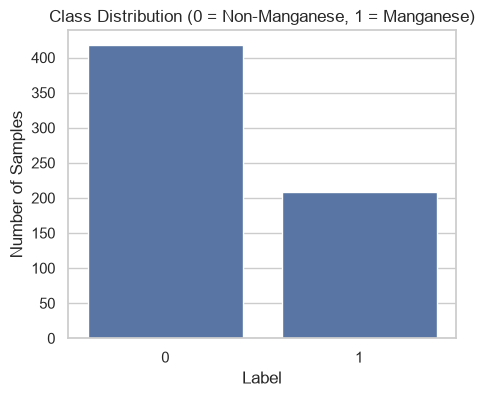

In [6]:
print(df["label"].value_counts())
print()
print(df["label"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="label")
plt.title("Class Distribution (0 = Non-Manganese, 1 = Manganese)")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.show()


In [7]:
district_balance = df.groupby("district")["label"].agg(["count", "mean"])
district_balance.columns = ["n_samples", "positive_rate"]
district_balance


,n_samples,positive_rate
district,,
Balaghat,282,0.343972
Bhandara,19,0.000000
Chhindwara,82,0.341463
Nagpur,244,0.344262


In [8]:
id_columns = ["sample_id", "grid_index", "x_utm_m", "y_utm_m"]
model_df = df.drop(columns=id_columns).copy()

categorical_features = ["lithology_class_id", "geomorphology_class_id", "bhuvan_lulc_class_id"]
excluded = categorical_features + ["label", "district"]
numerical_features = [c for c in model_df.columns if c not in excluded]

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)


Numerical features: ['S2_B2_Blue', 'S2_B3_Green', 'S2_B4_Red', 'S2_B5_RedEdge1', 'S2_B6_RedEdge2', 'S2_B7_RedEdge3', 'S2_B8A_NIR', 'S2_B11_SWIR1', 'S2_B12_SWIR2', 'S2_NDVI', 'S2_Fe_Oxide_Proxy', 'S2_SWIR_Ratio', 'Landsat_LST_C', 'S1_VV_dB', 'S1_VH_dB', 'S1_VV_VH_Difference_dB', 'distance_to_lineament_m', 'lineament_density_1km', 'distance_to_structure_m', 'structure_density_1km']

Categorical features: ['lithology_class_id', 'geomorphology_class_id', 'bhuvan_lulc_class_id']


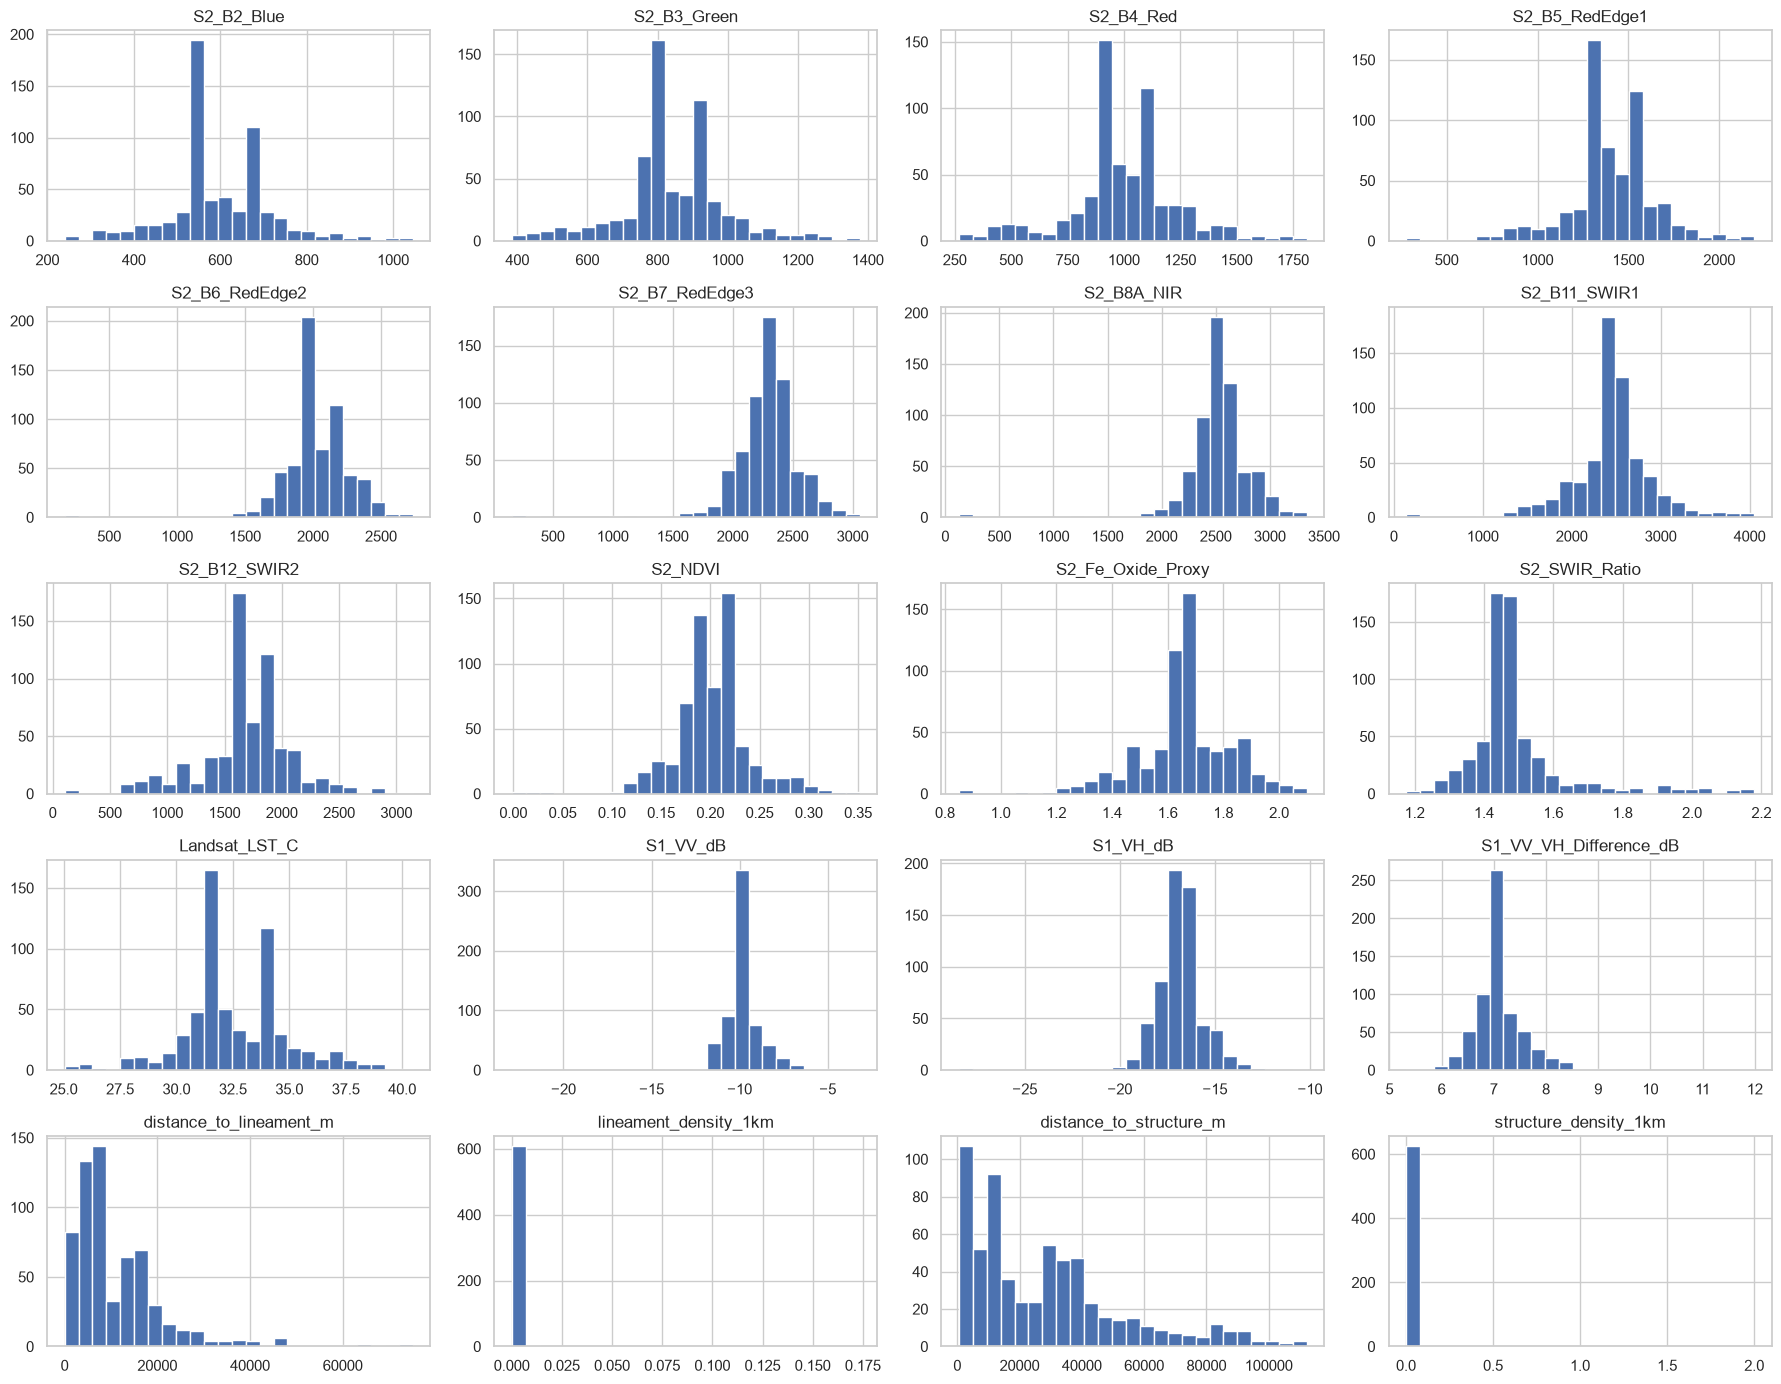

In [9]:
model_df[numerical_features].hist(figsize=(18, 14), bins=25)
plt.tight_layout()
plt.show()


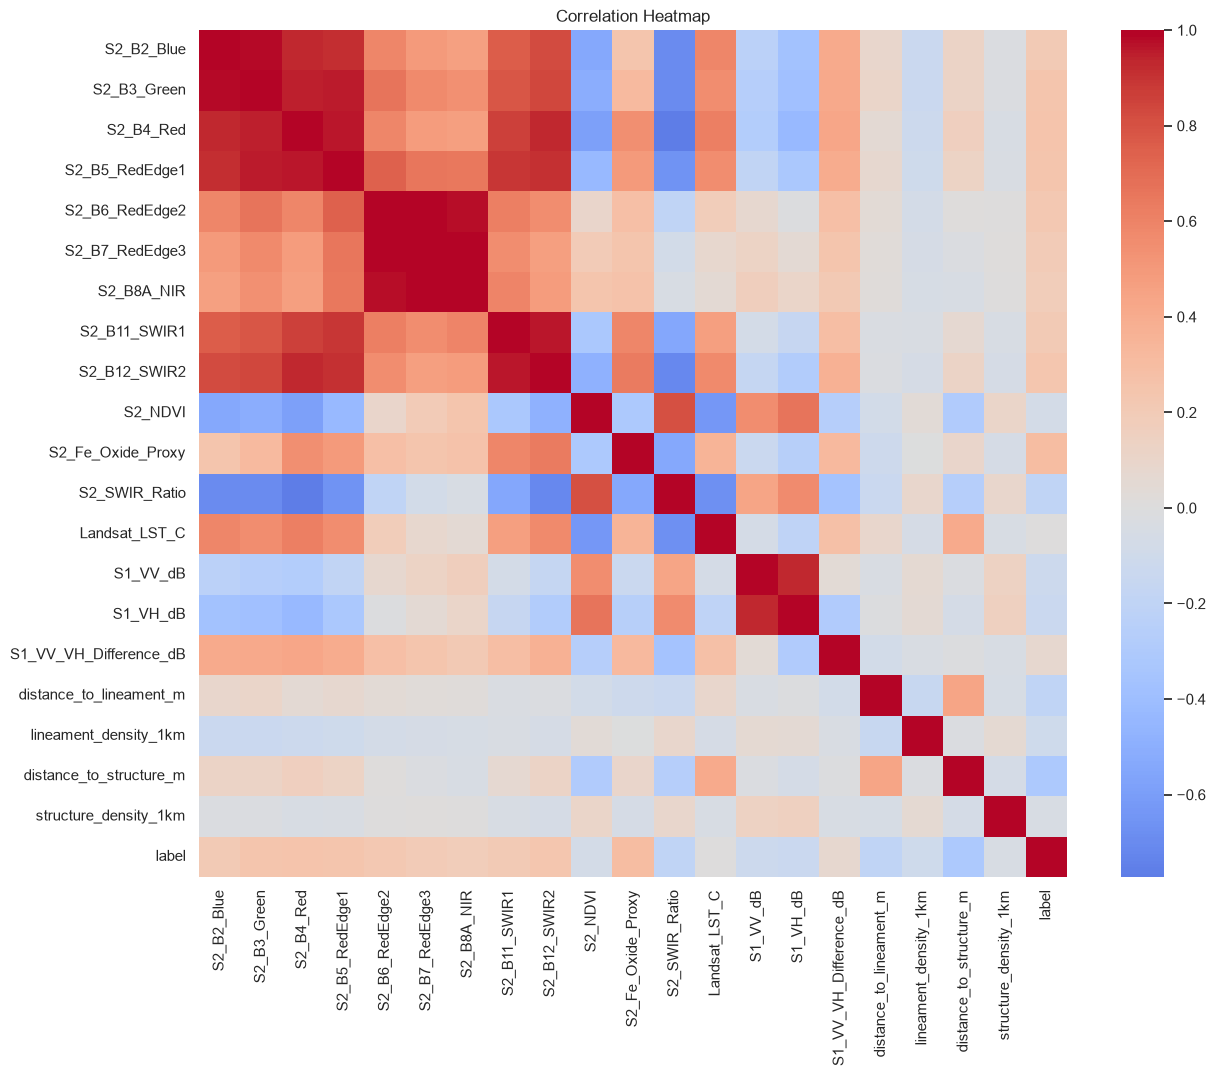

15 highly correlated (>0.85) feature pairs:
('S2_B7_RedEdge3', 'S2_B8A_NIR', 0.991)
('S2_B6_RedEdge2', 'S2_B7_RedEdge3', 0.99)
('S2_B2_Blue', 'S2_B3_Green', 0.98)
('S2_B6_RedEdge2', 'S2_B8A_NIR', 0.975)
('S2_B11_SWIR1', 'S2_B12_SWIR2', 0.964)
('S2_B4_Red', 'S2_B5_RedEdge1', 0.961)
('S2_B3_Green', 'S2_B5_RedEdge1', 0.953)
('S2_B3_Green', 'S2_B4_Red', 0.947)
('S2_B2_Blue', 'S2_B4_Red', 0.929)
('S2_B4_Red', 'S2_B12_SWIR2', 0.926)
('S1_VV_dB', 'S1_VH_dB', 0.924)
('S2_B2_Blue', 'S2_B5_RedEdge1', 0.916)
('S2_B5_RedEdge1', 'S2_B12_SWIR2', 0.906)
('S2_B5_RedEdge1', 'S2_B11_SWIR1', 0.89)
('S2_B4_Red', 'S2_B11_SWIR1', 0.856)


In [10]:
corr = model_df[numerical_features + ["label"]].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Explicit redundancy report: pairs with |r| > 0.85
pairs = []
cols = corr.columns[:-1]  # exclude label
c_abs = corr.loc[cols, cols].abs()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = c_abs.iloc[i, j]
        if v > 0.85:
            pairs.append((cols[i], cols[j], round(float(v), 3)))
pairs.sort(key=lambda x: -x[2])
print(f"{len(pairs)} highly correlated (>0.85) feature pairs:")
for p in pairs:
    print(p)


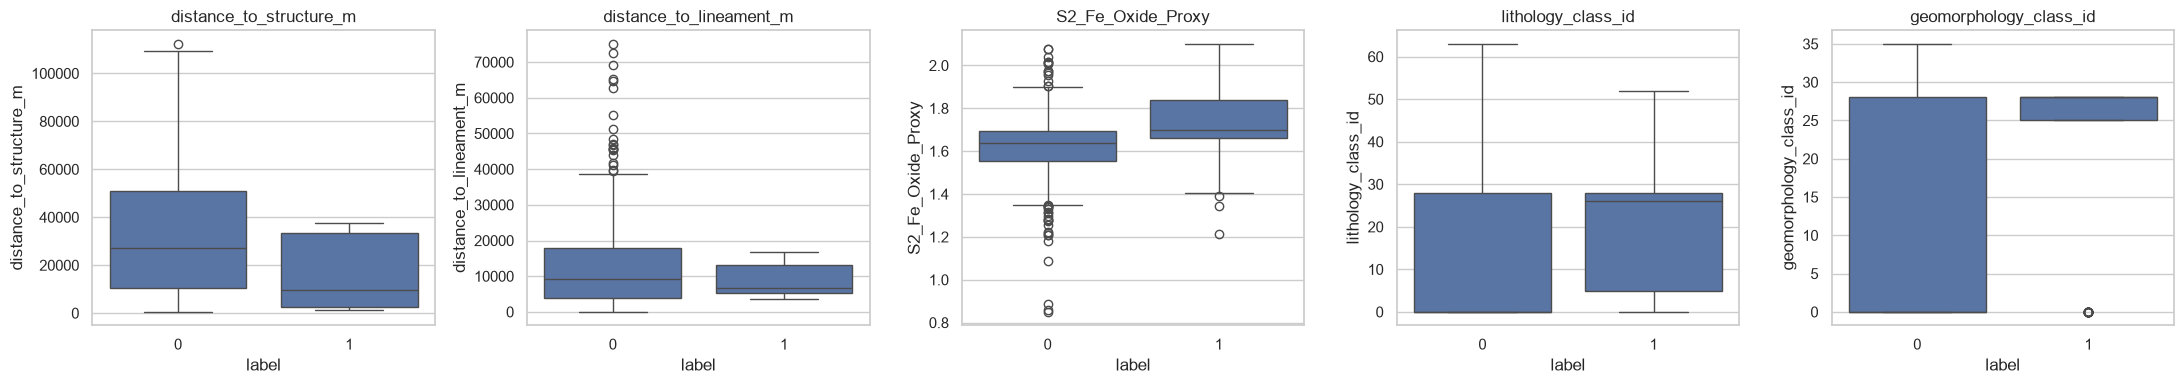

In [11]:
key_features = ["distance_to_structure_m", "distance_to_lineament_m",
                "S2_Fe_Oxide_Proxy", "lithology_class_id", "geomorphology_class_id"]

fig, axes = plt.subplots(1, len(key_features), figsize=(22, 4))
for ax, col in zip(axes, key_features):
    sns.boxplot(data=model_df, x="label", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [12]:
outlier_report = []
for col in numerical_features:
    q1, q3 = model_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((model_df[col] < lower) | (model_df[col] > upper)).sum()
    outlier_report.append([col, count, count / len(model_df) * 100])

outlier_df = pd.DataFrame(outlier_report, columns=["Feature", "Outlier_Count", "Outlier_Pct"])
outlier_df.sort_values("Outlier_Pct", ascending=False)


,Feature,Outlier_Count,Outlier_Pct
8,S2_B12_SWIR2,124,19.776715
13,S1_VV_dB,112,17.862839
2,S2_B4_Red,95,15.151515
11,S2_SWIR_Ratio,87,13.875598
7,S2_B11_SWIR1,83,13.237640
15,S1_VV_VH_Difference_dB,62,9.888357
3,S2_B5_RedEdge1,62,9.888357
14,S1_VH_dB,60,9.569378
9,S2_NDVI,60,9.569378
10,S2_Fe_Oxide_Proxy,57,9.090909


In [13]:
aucs = {}
for c in numerical_features + categorical_features:
    auc = roc_auc_score(df["label"], df[c])
    aucs[c] = max(auc, 1 - auc)

auc_series = pd.Series(aucs).sort_values(ascending=False)
auc_series


geomorphology_class_id     0.719638
S2_Fe_Oxide_Proxy          0.684857
lithology_class_id         0.682179
distance_to_structure_m    0.675820
S2_B4_Red                  0.637743
S2_B5_RedEdge1             0.636026
S2_B6_RedEdge2             0.630738
S2_B3_Green                0.628494
S2_B12_SWIR2               0.621077
S2_B8A_NIR                 0.619291
S2_B11_SWIR1               0.618289
S2_B7_RedEdge3             0.617963
S1_VH_dB                   0.609607
S1_VV_dB                   0.605504
S2_B2_Blue                 0.590468
S2_SWIR_Ratio              0.589009
bhuvan_lulc_class_id       0.587990
S1_VV_VH_Difference_dB     0.556449
distance_to_lineament_m    0.551292
S2_NDVI                    0.529189
lineament_density_1km      0.522727
Landsat_LST_C              0.506925
structure_density_1km      0.502392
dtype: float64

In [14]:
coords = df[["x_utm_m", "y_utm_m"]].values
tree = cKDTree(coords)
dist, idx = tree.query(coords, k=2)
nn_dist = dist[:, 1]
nn_idx = idx[:, 1]

print("Nearest-neighbor distance (m) stats:")
print(pd.Series(nn_dist).describe())

same_label_frac = (df["label"].values == df["label"].values[nn_idx]).mean()
print(f"\nFraction of nearest-neighbor pairs sharing the same label: {same_label_frac:.4f}")

feat_cols_all = numerical_features + categorical_features
X_all = df[feat_cols_all].values
X_nn = X_all[nn_idx]
nn_corr = {c: np.corrcoef(X_all[:, i], X_nn[:, i])[0, 1] for i, c in enumerate(feat_cols_all)}
pd.Series(nn_corr).sort_values(ascending=False)


Nearest-neighbor distance (m) stats:
count      627.000000
mean      3826.716169
std       4087.678163
min        100.000000
25%        100.000000
50%       3252.691193
75%       5949.369581
max      41761.226036
dtype: float64

Fraction of nearest-neighbor pairs sharing the same label: 0.9856


distance_to_structure_m    0.953916
distance_to_lineament_m    0.895229
geomorphology_class_id     0.868073
lithology_class_id         0.839910
Landsat_LST_C              0.710427
S2_NDVI                    0.591238
S2_Fe_Oxide_Proxy          0.564688
S2_B2_Blue                 0.539288
S2_SWIR_Ratio              0.536878
S2_B6_RedEdge2             0.535990
S2_B3_Green                0.529755
S2_B7_RedEdge3             0.527548
S2_B8A_NIR                 0.525836
S2_B5_RedEdge1             0.505033
bhuvan_lulc_class_id       0.489192
S1_VV_dB                   0.475384
S1_VH_dB                   0.471354
S2_B4_Red                  0.460120
S2_B12_SWIR2               0.427096
S2_B11_SWIR1               0.418818
S1_VV_VH_Difference_dB     0.415345
lineament_density_1km      0.017718
structure_density_1km     -0.004533
dtype: float64

In [15]:
X = df.drop(columns=["sample_id", "grid_index", "x_utm_m", "y_utm_m", "label", "district"])
y = df["label"]
groups = df["district"]  
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    remainder="passthrough",
)

neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = neg / pos

rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_split=5, min_samples_leaf=2,
        max_features="sqrt", class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    )),
])

xgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        eval_metric="logloss", scale_pos_weight=scale_pos_weight,
    )),
])

print(f"scale_pos_weight = {scale_pos_weight:.3f}")


scale_pos_weight = 2.000


In [16]:
gkf = GroupKFold(n_splits=groups.nunique())

for name, pipe in [("Random Forest", rf_pipe), ("XGBoost", xgb_pipe)]:
    aucs, accs, recalls, precisions = [], [], [], []
    for train_idx, test_idx in gkf.split(X, y, groups=groups):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)
        prob = pipe.predict_proba(X_te)[:, 1]
        accs.append(accuracy_score(y_te, pred))
        recalls.append(recall_score(y_te, pred, zero_division=0))
        precisions.append(precision_score(y_te, pred, zero_division=0))
        if y_te.nunique() > 1:
            aucs.append(roc_auc_score(y_te, prob))
    print(f"--- {name}: leave-one-district-out ---")
    print(f"Accuracy : mean={np.mean(accs):.3f}  folds={[round(a,3) for a in accs]}")
    print(f"Recall   : mean={np.mean(recalls):.3f}  folds={[round(r,3) for r in recalls]}")
    print(f"Precision: mean={np.mean(precisions):.3f}  folds={[round(p,3) for p in precisions]}")
    if aucs:
        print(f"ROC-AUC  : mean={np.mean(aucs):.3f}  folds={[round(a,3) for a in aucs]}")
    print()


--- Random Forest: leave-one-district-out ---
Accuracy : mean=0.721  folds=[0.621, 0.656, 0.659, 0.947]
Recall   : mean=0.013  folds=[0.052, 0.0, 0.0, 0.0]
Precision: mean=0.062  folds=[0.25, 0.0, 0.0, 0.0]
ROC-AUC  : mean=0.608  folds=[0.594, 0.648, 0.581]

--- XGBoost: leave-one-district-out ---
Accuracy : mean=0.739  folds=[0.645, 0.652, 0.659, 1.0]
Recall   : mean=0.000  folds=[0.0, 0.0, 0.0, 0.0]
Precision: mean=0.000  folds=[0.0, 0.0, 0.0, 0.0]
ROC-AUC  : mean=0.468  folds=[0.539, 0.46, 0.407]



In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

for name, pipe in [("Random Forest", rf_pipe), ("XGBoost", xgb_pipe)]:
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    print(f"--- {name}: random 80/20 split (INFLATED — for comparison only) ---")
    print(f"Accuracy : {accuracy_score(y_test, pred):.4f}")
    print(f"Precision: {precision_score(y_test, pred):.4f}")
    print(f"Recall   : {recall_score(y_test, pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, prob):.4f}")
    print()


--- Random Forest: random 80/20 split (INFLATED — for comparison only) ---
Accuracy : 0.9286
Precision: 0.8837
Recall   : 0.9048
F1 Score : 0.8941
ROC-AUC  : 0.9855

--- XGBoost: random 80/20 split (INFLATED — for comparison only) ---
Accuracy : 0.9762
Precision: 0.9333
Recall   : 1.0000
F1 Score : 0.9655
ROC-AUC  : 0.9997



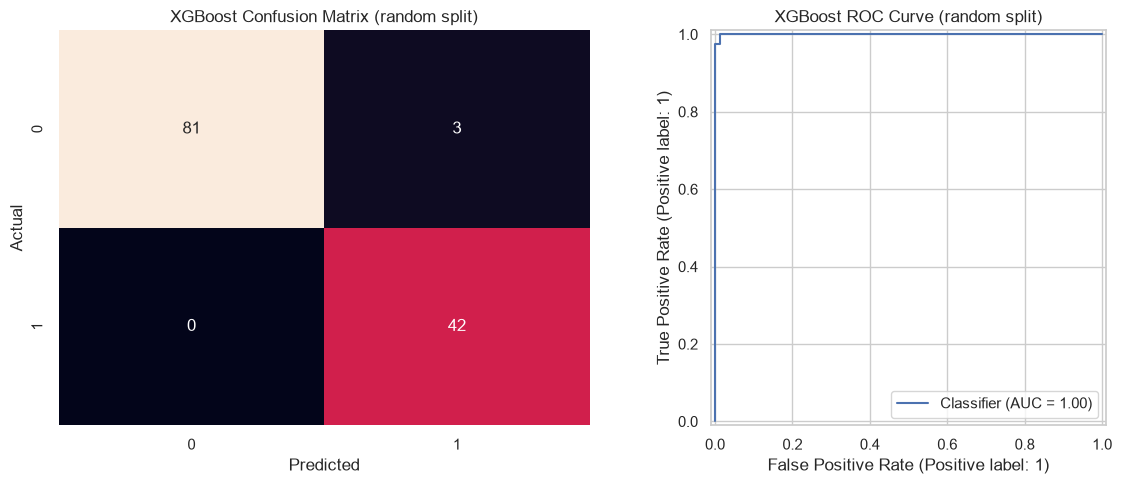

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pred_xgb = xgb_pipe.predict(X_test)
prob_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("XGBoost Confusion Matrix (random split)")

RocCurveDisplay.from_predictions(y_test, prob_xgb, ax=axes[1])
axes[1].set_title("XGBoost ROC Curve (random split)")

plt.tight_layout()
plt.show()


In [19]:

train_idx, test_idx = next(gkf.split(X, y, groups=groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

xgb_pipe.fit(X_tr, y_tr)

perm = permutation_importance(
    xgb_pipe, X_te, y_te, n_repeats=20, random_state=RANDOM_STATE, scoring="roc_auc"
)
perm_df = pd.DataFrame({
    "Feature": X_te.columns,
    "Importance_mean": perm.importances_mean,
    "Importance_std": perm.importances_std,
}).sort_values("Importance_mean", ascending=False)

perm_df.head(15)


,Feature,Importance_mean,Importance_std
18,distance_to_lineament_m,0.120787,0.020475
10,S2_Fe_Oxide_Proxy,0.032799,0.006685
14,S1_VH_dB,0.011218,0.006123
3,S2_B5_RedEdge1,0.005070,0.010986
22,bhuvan_lulc_class_id,0.004905,0.002468
12,Landsat_LST_C,0.004560,0.010046
7,S2_B11_SWIR1,0.003735,0.004435
0,S2_B2_Blue,0.002456,0.002558
17,geomorphology_class_id,0.000740,0.006705
11,S2_SWIR_Ratio,0.000543,0.002879


In [20]:
import joblib

joblib.dump(xgb_pipe, "manganese_xgboost.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']